In [209]:
import pandas as pd
import numpy as np
df = pd.read_csv("Telco-Customer-Churn.csv")

CheckPoint 1

In [210]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [211]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

In [212]:
X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"]

In [213]:
y = y.map({"No":0,"Yes":1})

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


CheckPoint 2

In [214]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

/var/folders/17/w2x9cwzs3dg9hp99ntwkxr4m0000gn/T/ipykernel_6353/2895413333.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


In [215]:
#Bu mərhələdə preprocessing prosesini `ColumnTransformer` və `Pipeline` vasitəsilə qurdum. Numerical sütunlara `StandardScaler`, 
#categorical sütunlara isə `OneHotEncoder` elədim. Daha sonra preprocessing addımlarını `Pipeline` daxilində birləşdirdim ki, bütün
#preprocessing əməliyyatları yalnız training datası üzərində öyrədilsin və data leakage-in qarşısı alınsın.

CheckPoint 3

In [216]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [217]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [218]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [219]:
logistic_pipeline.fit(X_train, y_train)

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [220]:
#Bu mərhələdə iki fərqli klassifikasiya modeli qurdum: Logistic Regression və Random Forest. Hər iki modeli preprocessing pipeline ilə birləşdirdim və training datası üzərində öyrətdim. Bu yanaşma ilə hər iki model eyni preprocessing addımlarından istifadə etdi.

CheckPoint4

In [221]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


In [222]:
y_pred_log = logistic_pipeline.predict(X_test)
y_prob_log = logistic_pipeline.predict_proba(X_test)[:, 1]


y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy :", round(accuracy_score(y_test, y_pred_log), 4))
print("Precision:", round(precision_score(y_test, y_pred_log), 4))
print("Recall   :", round(recall_score(y_test, y_pred_log), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_log), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_log), 4))


Logistic Regression
Accuracy : 0.7996
Precision: 0.6394
Recall   : 0.5642
F1 Score : 0.5994
ROC-AUC  : 0.8347


In [223]:
print("Random Forest")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

Random Forest
Accuracy : 0.7754
Precision: 0.6007
Recall   : 0.4626
F1 Score : 0.5227
ROC-AUC  : 0.8102


In [224]:
#Bu mərhələdə modelləri test datası üzərində qiymətləndirdim. Klassifikasiya problemi olduğu üçün yalnız accuracy ilə kifayətlənmədim. Modellərin performansını daha düzgün müqayisə etmək məqsədilə Precision, Recall, F1-Score və ROC-AUC metriklərindən istifadə etdim.Bu metriklər modellərin churn edəcək müştəriləri nə dərəcədə düzgün təxmin etdiyini və ümumi performansını daha ətraflı qiymətləndirməyə imkan verir.rir.

CheckPoint5

In [225]:
from sklearn.model_selection import cross_val_score

log_cv = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=5,
    scoring="f1"
)

rf_cv = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Logistic Regression F1 Scores:", log_cv)
print("Average F1:", round(log_cv.mean(), 4))

print()

print("Random Forest F1 Scores:", rf_cv)
print("Average F1:", round(rf_cv.mean(), 4))

Logistic Regression F1 Scores: [0.60667634 0.61538462 0.56186317 0.61781609 0.59084195]
Average F1: 0.5985

Random Forest F1 Scores: [0.56671664 0.55806938 0.50674663 0.51664025 0.55688623]
Average F1: 0.541


In [226]:
# Bu mərhələdə modellərin performansını daha etibarlı qiymətləndirmək üçün 5-fold Cross Validation tətbiq etdim. Qiymətləndirmə metrikası kimi
# F1-Score-dan istifadə etdim. Nəticələr göstərdi ki, Logistic Regression modelinin orta F1-Score-u (0.5985) Random Forest modelindən (0.5410)
# yüksəkdir. Bundan əlavə, Logistic Regression modelinin fold-lar üzrə nəticələri bir-birinə yaxın olduğundan model daha stabil performans göstərdi.

CheckPoint 6

In [227]:
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,num__TotalCharges,0.166284
1,num__MonthlyCharges,0.145147
0,num__tenure,0.143637
35,cat__Contract_Month-to-month,0.054488
26,cat__TechSupport_No,0.034825
42,cat__PaymentMethod_Electronic check,0.029073
17,cat__OnlineSecurity_No,0.027557
15,cat__InternetService_Fiber optic,0.019518
4,cat__gender_Male,0.018430
3,cat__gender_Female,0.017766


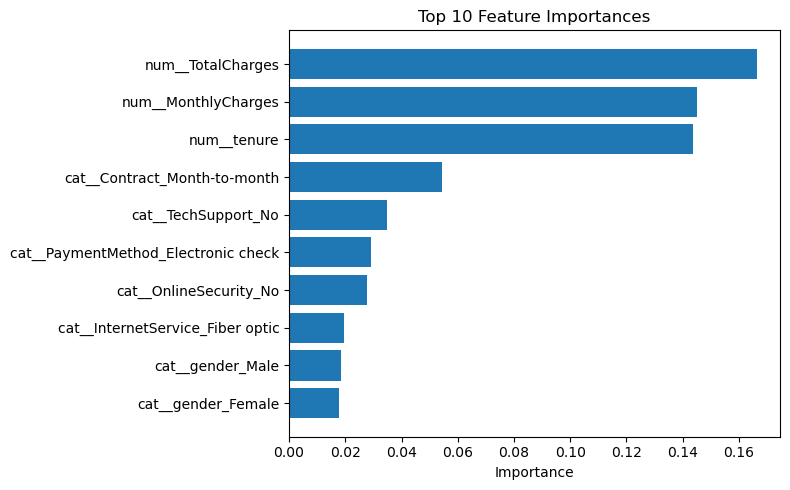

In [228]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [229]:
#Bu mərhələdə Random Forest modelinin Feature Importance nəticələrini analiz etdim. Nəticələr göstərdi ki, model qərar verərkən bəzi
#xüsusiyyətlər digərlərindən daha çox təsir göstərir. Ən vacib xüsusiyyətlər əsasən müqavilə növü (Contract), müştərinin xidmət
#müddəti (tenure), aylıq ödəniş (MonthlyCharges), ümumi ödəniş (TotalCharges) və bəzi əlavə xidmətlərlə (məsələn, OnlineSecurity və TechSupport) 
#bağlı dəyişənlər oldu. Bu nəticələr göstərir ki, müştərinin xidmət tarixi və istifadə etdiyi xidmətlər churn ehtimalının proqnozlaşdırılmasında 
#mühüm rol oynayır.